In [2]:
import unicodedata
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def remove_accents(text):#去除西语名字音调
    if pd.isna(text):
        return text
    text = str(text)
    text = unicodedata.normalize('NFKD', text)
    text = ''.join(c for c in text if not unicodedata.combining(c))
    return text

def ip_to_outs(IP):
    whole = int(IP)
    frac = round(IP - whole, 1)
    return whole * 3 + int(frac * 10)

def outs_to_ip(outs):
    return outs // 3 + (outs % 3) / 10


df = pd.read_excel('pitchers2025regular.xlsx')
df = df.rename(columns={'WAR': 'rWAR'})
df_fwar = pd.read_excel('fangraphWar25.xlsx')
df_fwar = df_fwar.rename(columns={'Name': 'Player'})
df_fwar = df_fwar.rename(columns={'Pit WAR': 'fWAR'})
df['Player'] = df['Player'].str.replace('*', '', regex=False)#去掉名字后面的*

df['outs'] = df['IP'].apply(ip_to_outs)

df_fwar['IP'] = df_fwar['IP'].fillna(0)
df_fwar['outs'] = df_fwar['IP'].apply(ip_to_outs)

df['K_Per'] = (df['SO'] / df['BF'] * 100).round(1)
df['BB_Per'] = (df['BB'] / df['BF'] * 100).round(1)

df['Role'] = 0
df.loc[df['outs'] >= 140*3, 'Role'] = 1
df_fwar['Role'] = 0
df_fwar.loc[df_fwar['outs'] >= 140*3, 'Role'] = 1

In [3]:
df['player_norm'] = df['Player'].apply(remove_accents)
df_fwar['player_norm'] = df_fwar['Player'].apply(remove_accents)


df = df.merge(
    df_fwar[['player_norm','Role','fWAR']],
    on=['player_norm','Role'], 
    how='left'
)

df = df.drop(columns=['Player-additional', 'Awards', 'player_norm','W-L%'],errors= 'ignore')

df['WAR_dif'] = df['fWAR']-df['rWAR']

df['HR_Per'] = (((df['HR']) / df['H']) * 100).round(2)

df[df['Role'] == 1].sort_values(by='HR_Per', ascending=False)


,Rk,Player,Age,Team,Lg,rWAR,W,L,ERA,G,...,BB9,SO9,SO/BB,outs,K_Per,BB_Per,Role,fWAR,WAR_dif,HR_Per
76,77,Shota Imanaga,31,CHC,NL,1.5,9,8,3.73,25,...,1.6,7.3,4.50,434,20.6,4.6,1,0.9,-0.6,26.50
28,29,Jacob deGrom,37,TEX,AL,2.9,12,8,2.97,30,...,1.9,9.6,5.00,518,27.7,5.5,1,3.4,0.5,21.31
11,12,Zack Littell,29,2TM,2LG,3.2,10,8,3.81,32,...,1.5,6.3,4.06,560,17.1,4.2,1,1.5,-1.7,20.69
74,75,Seth Lugo,35,KCR,AL,1.7,8,7,4.15,26,...,3.4,7.7,2.27,436,20.5,9.0,1,0.5,-1.2,20.30
20,21,Jake Irvin,28,WSN,NL,-0.4,9,13,5.70,33,...,3.1,6.2,2.00,540,15.8,7.9,1,-0.4,0.0,19.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9,10,Paul Skenes,23,PIT,NL,7.7,10,10,1.97,32,...,2.0,10.4,5.14,563,29.5,5.7,1,6.5,-1.2,8.09
35,36,José Soriano,26,LAA,AL,2.4,10,11,4.26,31,...,4.2,8.1,1.95,507,21.0,10.8,1,3.0,0.6,7.59
2,3,Cristopher Sánchez,28,PHI,NL,8.0,13,5,2.50,32,...,2.0,9.4,4.82,606,26.3,5.5,1,6.4,-1.6,7.02
0,1,Logan Webb,28,SFG,NL,3.8,15,11,3.22,34,...,2.0,9.7,4.87,621,26.2,5.4,1,5.5,1.7,6.67


In [10]:
df_starters = df[df['Role'] == 1].copy()
df_bullpen = df[df['Role'] == 0].copy()

# df_starters['HR_Per'].corr(df_starters['FIP'])
# df_starters['HR_Per'].corr(df_starters['fWAR'])


np.float64(0.5343443768367818)

In [5]:
df.loc[
    (df['Role'] == 1) & (df['WAR_dif'] > 1)
]['ERA'].mean()#np.float64(4.606086956521739)

df.loc[
    (df['Role'] == 1) & (df['WAR_dif'] < 0.5)
]['ERA'].mean()#np.float64(3.6461224489795923)

#ERA越低,WAR差异越小

np.float64(3.6461224489795923)

Text(0.5, 1.0, 'WAR_dif Boxplot')

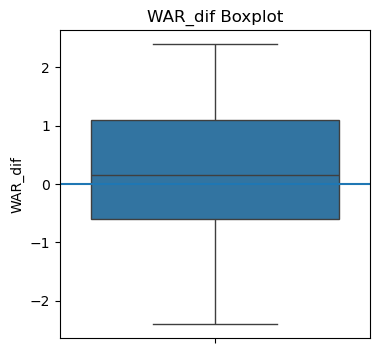

In [27]:
plt.figure(figsize=(4,4))
sns.boxplot(y=df_starters['WAR_dif'])
plt.axhline(0)
plt.title('WAR_dif Boxplot')

In [40]:
df_starters.sort_values(by="WAR_dif",ascending=False).head(10)['ERA'].mean()#np.float64(4.521)
df_starters.sort_values(by="WAR_dif",ascending=False).head(10)['FIP'].mean()#np.float64(3.9300000000000006)
df_starters.sort_values(by="WAR_dif",ascending=False).head(10)['IP'].mean()#np.float64(165.93)

df_starters.sort_values(by="WAR_dif",ascending=True).head(10)['ERA'].mean()#np.float64(2.9720000000000004)
df_starters.sort_values(by="WAR_dif",ascending=True).head(10)['FIP'].mean()#np.float64(3.7129999999999996)
df_starters.sort_values(by="WAR_dif",ascending=True).head(10)['IP'].mean()#np.float64(172.42)

df_bullpen.sort_values(by="WAR_dif",ascending=False).head(10)['ERA'].mean()#np.float64(5.032)
df_bullpen.sort_values(by="WAR_dif",ascending=False).head(10)['FIP'].mean()#np.float64(3.125)
df_bullpen.sort_values(by="WAR_dif",ascending=False).head(10)['IP'].mean()#np.float64(72.86000000000001)

df_bullpen.sort_values(by="WAR_dif",ascending=True).head(10)['ERA'].mean()#np.float64(2.7089999999999996)
df_bullpen.sort_values(by="WAR_dif",ascending=True).head(10)['FIP'].mean()#np.float64(3.8560000000000003)
df_bullpen.sort_values(by="WAR_dif",ascending=True).head(10)['IP'].mean()#np.float64(95.42)

#结论:当 WAR_dif 极端时，本质反映的是“结果导向（bWAR）” 与 “过程导向（fWAR）” 在不同角色、不同样本规模下的系统性偏差。

np.float64(4.521)

In [59]:
df_starters.sort_values(by="WAR_dif",ascending=False).head(10)[['Player','K_Per', 'BB_Per','HR_Per','WAR_dif']]


,Player,K_Per,BB_Per,HR_Per,WAR_dif
78,Taj Bradley,21.0,9.3,14.50,2.4
63,Patrick Corbin,19.8,7.7,13.04,2.3
37,Dylan Cease,29.8,9.8,13.82,2.3
19,Sonny Gray,26.7,5.0,13.51,2.2
47,Mitchell Parker,14.2,8.0,14.04,2.1
49,Andre Pallante,15.5,8.7,12.14,1.9
67,Jack Leiter,22.9,10.4,14.17,1.9
0,Logan Webb,26.2,5.4,6.67,1.7
36,David Peterson,20.7,9.0,6.63,1.7
52,Jack Flaherty,27.6,8.7,15.65,1.7


In [60]:
df_starters.sort_values(by="WAR_dif",ascending=True).head(10)[['Player','K_Per', 'BB_Per','HR_Per','WAR_dif']]


,Player,K_Per,BB_Per,HR_Per,WAR_dif
39,Gavin Williams,24.6,11.8,17.69,-2.4
60,Nick Lodolo,24.3,4.8,15.94,-2.1
69,Drew Rasmussen,21.7,6.3,15.52,-1.9
23,Freddy Peralta,28.2,9.1,16.94,-1.9
11,Zack Littell,17.1,4.2,20.69,-1.7
41,Andrew Abbott,21.8,6.3,12.84,-1.7
2,Cristopher Sánchez,26.3,5.5,7.02,-1.6
17,Nick Pivetta,26.4,6.9,17.05,-1.6
65,Ryne Nelson,21.3,6.6,13.71,-1.5
12,Hunter Brown,28.3,7.8,12.78,-1.5


In [65]:
df.loc[:,['Player','HR_Per']]
df[df['Role'] == 1].sort_values(by='WAR_dif', ascending=False)
df['WAR_dif'].corr(df['HR_Per'])


df.loc[[78, 39]]


,Rk,Player,Age,Team,Lg,rWAR,W,L,ERA,G,...,BB9,SO9,SO/BB,outs,K_Per,BB_Per,Role,fWAR,WAR_dif,HR_Per
78,79,Taj Bradley,24,2TM,AL,-0.6,6,8,5.05,27,...,3.5,8.0,2.27,428,21.0,9.3,1,1.8,2.4,14.50
39,40,Gavin Williams,25,CLE,AL,3.8,12,5,3.06,31,...,4.5,9.3,2.08,503,24.6,11.8,1,1.4,-2.4,17.69
